In [114]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [147]:
df = pd.read_csv("../cleaning/movies_clean.csv")
df.head()

,id,title,release_date,popularity,vote_average,vote_count,release_year,release_month,film_age,log_vote_count,...,genre_9648,genre_53,genre_80,genre_99,genre_878,genre_10749,genre_10751,genre_count,trend_score,popularity_score
0,1472951,Infiltrate,2026-04-10,56.4441,5.300,8,2026,4,0,2.197225,...,0,1,0,0,0,0,0,2,56.444100,451.5528
1,615,The Passion of the Christ,2004-02-25,55.8709,7.538,5155,2004,2,22,8.547916,...,0,0,0,0,0,0,0,1,2.429170,288014.4895
2,875828,Peaky Blinders: The Immortal Man,2026-03-05,49.9926,7.225,793,2026,3,0,6.677083,...,0,0,1,0,0,0,0,2,49.992600,39644.1318
3,1272837,28 Years Later: The Bone Temple,2026-01-14,49.8691,7.152,1029,2026,1,0,6.937314,...,0,1,0,0,1,0,0,3,49.869100,51315.3039
4,300496,Nefeli,1980-01-01,49.5016,2.500,6,1980,1,46,1.945910,...,0,0,0,0,0,1,0,1,1.053226,297.0096


dividing data into training dataset and testing dataset

In [149]:
X = df.select_dtypes(include=[np.number])
X = X.drop(columns=['vote_average'])  # jistota

y = df['vote_average']

In [150]:
X = df.select_dtypes(include=[np.number])
X = X.drop(columns=['vote_average', 'id'])
y = df['vote_average']

In [151]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Function takes in model and train it
after that is gonna print out the metrics such as
How much on average is model wrong,
How big the mistakes are,How much does model understand the data


In [152]:
results = []

def evaluate(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

    print(f"\n {name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-"*40)

In [153]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
evaluate(ridge, "Ridge Regression")


 Ridge Regression
MAE: 0.49319785336946526
RMSE: 0.6577721865787595
R2: 0.39088092920867956
----------------------------------------


In [154]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

evaluate(rf, "Random Forest")


 Random Forest
MAE: 0.4439061314067613
RMSE: 0.5961089814120251
R2: 0.49973223927561594
----------------------------------------



 XGBoost
MAE: 0.43613989546930776
RMSE: 0.5826319164065238
R2: 0.5220970311423181
----------------------------------------


<Figure size 1000x600 with 0 Axes>

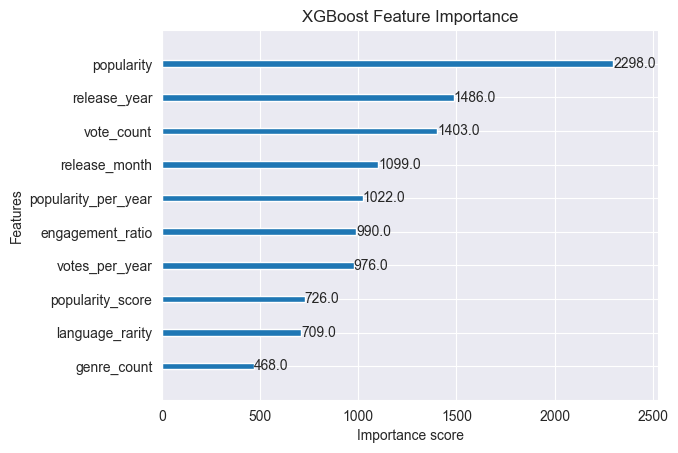

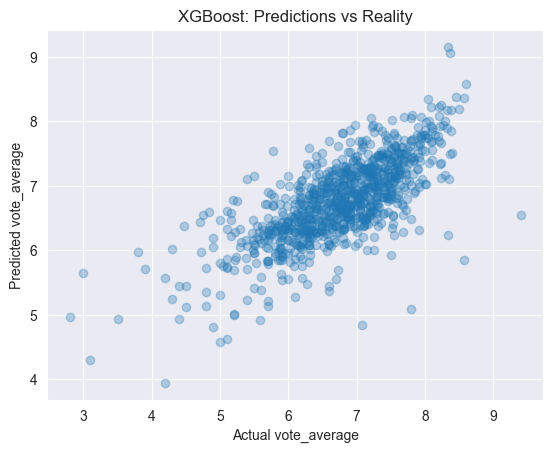

In [155]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

evaluate(xgb, "XGBoost")
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10,6))
plot_importance(xgb, max_num_features=10)
plt.title("XGBoost Feature Importance")
plt.show()
pred = xgb.predict(X_test)
plt.scatter(y_test, pred, alpha=0.3)
plt.xlabel("Actual vote_average")
plt.ylabel("Predicted vote_average")
plt.title("XGBoost: Predictions vs Reality")
plt.show()

In [156]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42
)

evaluate(mlp, "Neural Network (MLP)")


 Neural Network (MLP)
MAE: 2.4769300899792652
RMSE: 3.8073406634605
R2: -19.407728130804845
----------------------------------------


In [157]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_df.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
2,XGBoost,0.436140,0.582632,0.522097
1,Random Forest,0.443906,0.596109,0.499732
0,Ridge Regression,0.493198,0.657772,0.390881
3,Neural Network (MLP),2.476930,3.807341,-19.407728


Decide to use XGBoost because of low amounts of errors because mae and how well it understand data thanks to metrics r2

In [158]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results_cv = []

In [159]:
def evaluate_cv(model, name):
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='r2'   # můžeš změnit na 'neg_mean_absolute_error'
    )

    results_cv.append([
        name,
        scores.mean(),
        scores.std()
    ])

    print(f"\n{name}")
    print("R2 scores:", scores)
    print("Mean R2:", scores.mean())
    print("Std:", scores.std())
    print("-"*40)

In [160]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

ridge = Ridge(alpha=1.0)
evaluate_cv(ridge, "Ridge Regression")

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
evaluate_cv(rf, "Random Forest")

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
evaluate_cv(xgb, "XGBoost")

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42
)
evaluate_cv(mlp, "Neural Network (MLP)")


Ridge Regression
R2 scores: [0.39088093 0.34444455 0.4018698  0.38769854 0.37545362]
Mean R2: 0.38006948858264444
Std: 0.01970170603025839
----------------------------------------

Random Forest
R2 scores: [0.50204021 0.48736141 0.51235702 0.51194934 0.45638823]
Mean R2: 0.494019243301821
Std: 0.0208926694490953
----------------------------------------

XGBoost
R2 scores: [0.52209703 0.47204981 0.54374383 0.5050197  0.49647708]
Mean R2: 0.5078774880244267
Std: 0.024126122208707676
----------------------------------------

Neural Network (MLP)
R2 scores: [-11.57780125 -17.88529243  -5.10996176 -12.39700937 -69.47272876]
Mean R2: -23.28855871196377
Std: 23.445263592647745
----------------------------------------


In [161]:
cv_df = pd.DataFrame(
    results_cv,
    columns=["Model", "Mean R2", "Std"]
)

cv_df.sort_values(by="Mean R2", ascending=False)

,Model,Mean R2,Std
2,XGBoost,0.507877,0.024126
1,Random Forest,0.494019,0.020893
0,Ridge Regression,0.380069,0.019702
3,Neural Network (MLP),-23.288559,23.445264


In [162]:
from xgboost import XGBRegressor
import joblib

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)


xgb.fit(X, y)


joblib.dump(xgb, "../models/xgb_model.pkl")
joblib.dump(X.columns.tolist(), "../models/features.pkl")

print("Model uložen OK")

Model uložen OK
